# Exploratory Data Analysis on Cardiotocographic Dataset

## Objective

The main goal of this assignment is to conduct a thorough exploratory analysis of the Cardiotocographic dataset to uncover insights, identify patterns, and understand the dataset's underlying structure.

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
# Load the Cardiotocographic dataset

df = pd.read_csv("Cardiotocographic.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [67]:
# Display the first 5 rows

df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [68]:
# Check the number of rows and columns

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 2126
Number of columns: 14


In [69]:
# Check data types of all columns

print(df.dtypes)

LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Tendency    float64
NSP         float64
dtype: object


In [70]:
# Check for duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 2


In [71]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values in each column:
LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

Total missing values: 167


In [72]:
# Handle missing values

# Remove rows where the target variable NSP is missing
df = df.dropna(subset=["NSP"])

# Fill missing values in feature columns using the median
feature_columns = df.columns.drop("NSP")

for column in feature_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].median())

print("Missing values after treatment:")
print(df.isnull().sum())

print("\nTotal missing values after treatment:",
      df.isnull().sum().sum())

Missing values after treatment:
LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Tendency    0
NSP         0
dtype: int64

Total missing values after treatment: 0


In [73]:
# Remove duplicate rows

print("Duplicate rows before removal:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate rows after removal:", df.duplicated().sum())
print("Final number of rows:", df.shape[0])

Duplicate rows before removal: 2
Duplicate rows after removal: 0
Final number of rows: 2103


In [74]:
# Detect outliers using the IQR method

numeric_columns = df.select_dtypes(include=np.number).columns

outlier_summary = []

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()

    outlier_summary.append({
        "Column": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Number of Outliers": outliers
    })

outlier_df = pd.DataFrame(outlier_summary)

print("Outlier Summary:")
print(outlier_df)

Outlier Summary:
      Column          Q1          Q3        IQR  Lower Bound  Upper Bound  \
0         LB  126.000000  140.000000  14.000000   105.000000   161.000000   
1         AC    0.000000    0.005650   0.005650    -0.008475     0.014124   
2         FM    0.000000    0.002559   0.002559    -0.003839     0.006398   
3         UC    0.001838    0.006543   0.004705    -0.005219     0.013601   
4         DL    0.000000    0.003295   0.003295    -0.004942     0.008237   
5         DS    0.000000    0.000000   0.000000     0.000000     0.000000   
6         DP    0.000000    0.000000   0.000000     0.000000     0.000000   
7       ASTV   32.000000   61.000000  29.000000   -11.500000   104.500000   
8       MSTV    0.700000    1.700000   1.000000    -0.800000     3.200000   
9       ALTV    0.000000   11.000000  11.000000   -16.500000    27.500000   
10      MLTV    4.600000   10.900000   6.300000    -4.850000    20.350000   
11     Width   37.000000  100.000000  63.000000   -57.50000

In [75]:
# Treat outliers using IQR capping

# Columns selected for outlier treatment
outlier_columns = [
    "LB", "AC", "FM", "UC", "DL",
    "ASTV", "MSTV", "ALTV", "MLTV", "Width"
]

for column in outlier_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap extreme values
    df[column] = df[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

print("Outlier treatment completed using IQR capping.")

Outlier treatment completed using IQR capping.


In [76]:
# Verify the cleaned dataset

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Rows: 2103
Columns: 14

Missing values:
0

Duplicate rows:
0


In [77]:
# Treat outliers using IQR capping

# Columns selected for outlier treatment
outlier_columns = [
    "LB", "AC", "FM", "UC", "DL",
    "ASTV", "MSTV", "ALTV", "MLTV", "Width"
]

for column in outlier_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap extreme values
    df[column] = df[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

print("Outlier treatment completed using IQR capping.")

Outlier treatment completed using IQR capping.


In [78]:
# Verify the cleaned dataset

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Rows: 2103
Columns: 14

Missing values:
0

Duplicate rows:
0


In [79]:
# Statistical Summary

numeric_columns = df.select_dtypes(include=np.number).columns

mean_values = df[numeric_columns].mean()
median_values = df[numeric_columns].median()
std_values = df[numeric_columns].std()

print("========== MEAN ==========")
print(mean_values)

print("\n========== MEDIAN ==========")
print(median_values)

print("\n========== STANDARD DEVIATION ==========")
print(std_values)

========== MEAN ==========
LB          133.291604
AC            0.003144
FM            0.001565
UC            0.004361
DL            0.001770
DS            0.000003
DP            0.000175
ASTV         46.999304
MSTV          1.301912
ALTV          6.733464
MLTV          8.017610
Width        70.351685
Tendency      0.316672
NSP           1.304797
dtype: float64

========== MEDIAN ==========
LB          133.000000
AC            0.001631
FM            0.000000
UC            0.004484
DL            0.000000
DS            0.000000
DP            0.000000
ASTV         49.000000
MSTV          1.200000
ALTV          0.000000
MLTV          7.400000
Width        67.486468
Tendency      0.000000
NSP           1.000000
dtype: float64

========== STANDARD DEVIATION ==========
LB           9.976211
AC           0.003844
FM           0.002477
UC           0.003008
DL           0.002675
DS           0.000142
DP           0.000840
ASTV        17.633594
MSTV         0.779896
ALTV        10.400402
MLTV   

In [80]:
# Interquartile Range (IQR)

Q1 = df[numeric_columns].quantile(0.25)
Q3 = df[numeric_columns].quantile(0.75)

IQR = Q3 - Q1

print("========== IQR ==========")
print(IQR)

========== IQR ==========
LB          14.000000
AC           0.005650
FM           0.002559
UC           0.004705
DL           0.003295
DS           0.000000
DP           0.000000
ASTV        29.000000
MSTV         1.000000
ALTV        11.000000
MLTV         6.300000
Width       63.000000
Tendency     1.000000
NSP          0.000000
dtype: float64


In [81]:
# Combined Statistical Summary

statistical_summary = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Standard Deviation": df[numeric_columns].std(),
    "IQR": df[numeric_columns].quantile(0.75)
          - df[numeric_columns].quantile(0.25)
})

print("Complete Statistical Summary:")
print(statistical_summary)

Complete Statistical Summary:
                Mean      Median  Standard Deviation        IQR
LB        133.291604  133.000000            9.976211  14.000000
AC          0.003144    0.001631            0.003844   0.005650
FM          0.001565    0.000000            0.002477   0.002559
UC          0.004361    0.004484            0.003008   0.004705
DL          0.001770    0.000000            0.002675   0.003295
DS          0.000003    0.000000            0.000142   0.000000
DP          0.000175    0.000000            0.000840   0.000000
ASTV       46.999304   49.000000           17.633594  29.000000
MSTV        1.301912    1.200000            0.779896   1.000000
ALTV        6.733464    0.000000           10.400402  11.000000
MLTV        8.017610    7.400000            5.094192   6.300000
Width      70.351685   67.486468           39.773195  63.000000
Tendency    0.316672    0.000000            0.645855   1.000000
NSP         1.304797    1.000000            0.644857   0.000000


## Interesting Statistical Findings

- LB has a mean of approximately 133.22 and a median of 133, indicating that the central tendency is quite similar.
- ASTV shows considerable variability, with a standard deviation of approximately 17.63 and an IQR of 29.
- Width has relatively high variability, with a standard deviation of approximately 39.77 and an IQR of 63.
- MSTV has a relatively small scale compared with variables such as LB and Width.
- Several variables such as AC, FM, UC, DL, DS, and DP have very small numerical values compared with LB, ASTV, and Width.

# 3. Data Visualization

Visualizations are used to understand the distributions, variability, relationships, and patterns present in the dataset.

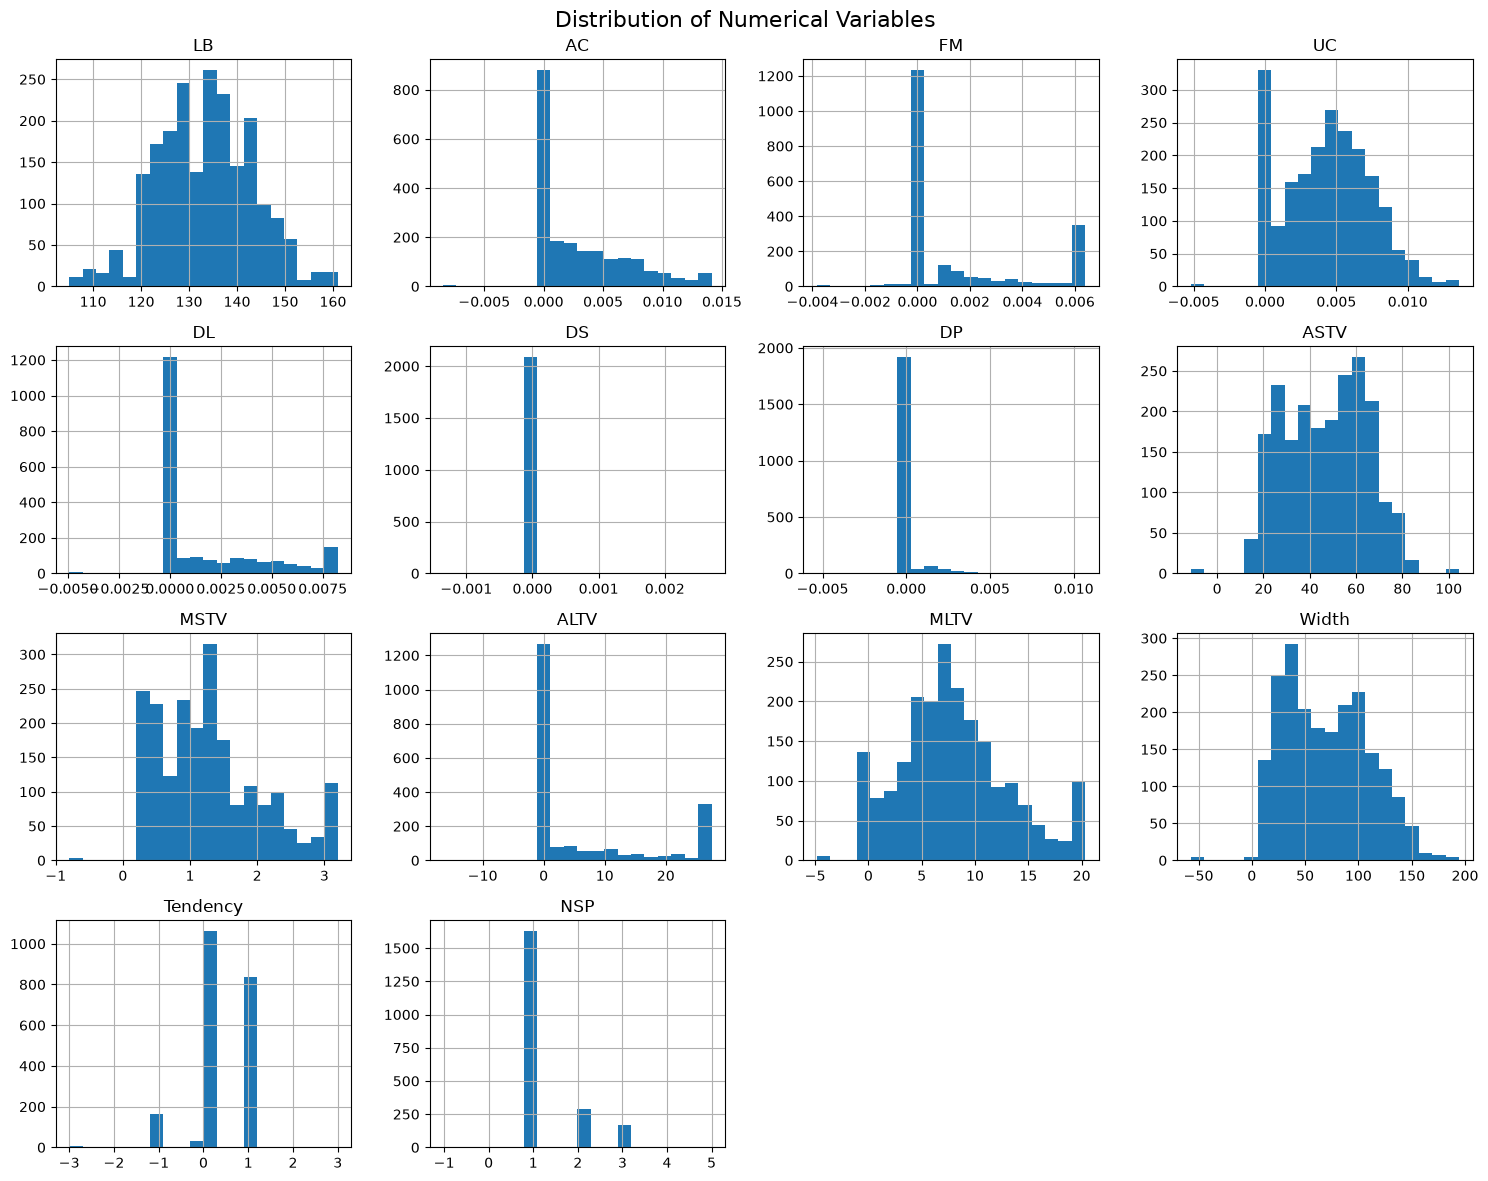

In [82]:
# Histograms of numerical variables

df[numeric_columns].hist(
    figsize=(15, 12),
    bins=20
)

plt.suptitle("Distribution of Numerical Variables", fontsize=16)
plt.tight_layout()
plt.show()

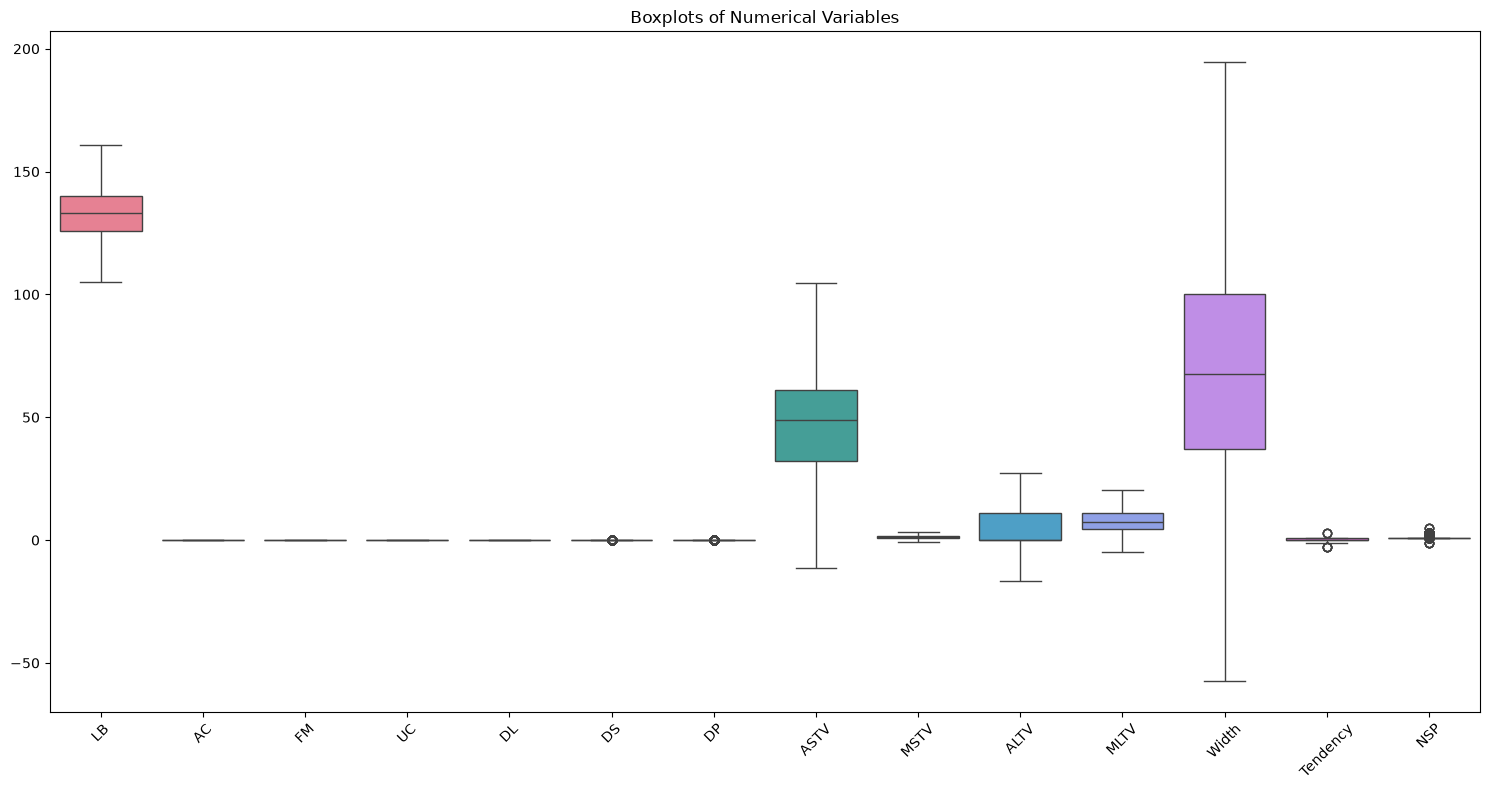

In [83]:
# Boxplots of numerical variables

plt.figure(figsize=(15, 8))

sns.boxplot(data=df[numeric_columns])

plt.title("Boxplots of Numerical Variables")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

NSP Category Counts:
NSP_Category
Normal (1)          1544
Suspect (2)          280
Pathological (3)     164
Other/Invalid        115
Name: count, dtype: int64


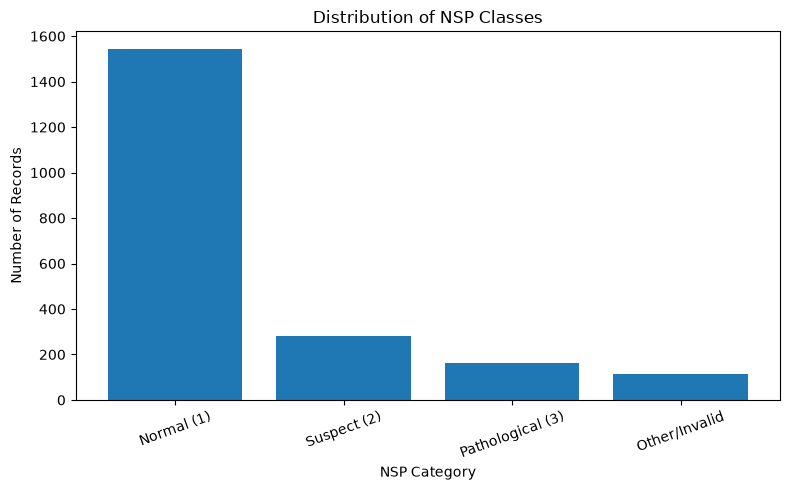

In [84]:
# Create NSP categories for visualization

def nsp_label(value):
    if pd.isna(value):
        return "Missing"
    elif value == 1:
        return "Normal (1)"
    elif value == 2:
        return "Suspect (2)"
    elif value == 3:
        return "Pathological (3)"
    else:
        return "Other/Invalid"

df["NSP_Category"] = df["NSP"].apply(nsp_label)

# Count each category
nsp_counts = df["NSP_Category"].value_counts()

print("NSP Category Counts:")
print(nsp_counts)

# Plot
plt.figure(figsize=(8, 5))
plt.bar(nsp_counts.index, nsp_counts.values)

plt.title("Distribution of NSP Classes")
plt.xlabel("NSP Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [85]:
numeric_columns = df.select_dtypes(include=np.number).columns

In [86]:
numeric_columns = df.select_dtypes(include=np.number).columns.drop("NSP")

In [87]:
# Reload the original dataset
df = pd.read_csv("Cardiotocographic.csv")

print("Original dataset reloaded")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Original dataset reloaded
Rows: 2126
Columns: 14


In [88]:
print("NSP Class Distribution:")
print(df["NSP"].value_counts().sort_index())

NSP Class Distribution:
NSP
-1.025988    1
-1.000000    5
 0.967075    1
 0.969447    1
 0.972305    1
            ..
 3.015185    1
 3.019152    1
 3.020038    1
 3.034545    1
 5.000000    4
Name: count, Length: 111, dtype: int64


In [89]:
numeric_columns = df.select_dtypes(include=np.number).columns.drop("NSP")

In [90]:
df = pd.read_csv("Cardiotocographic.csv")

print(df.shape)
print(df["NSP"].value_counts().sort_index())

(2126, 14)
NSP
-1.025988    1
-1.000000    5
 0.967075    1
 0.969447    1
 0.972305    1
            ..
 3.015185    1
 3.019152    1
 3.020038    1
 3.034545    1
 5.000000    4
Name: count, Length: 111, dtype: int64


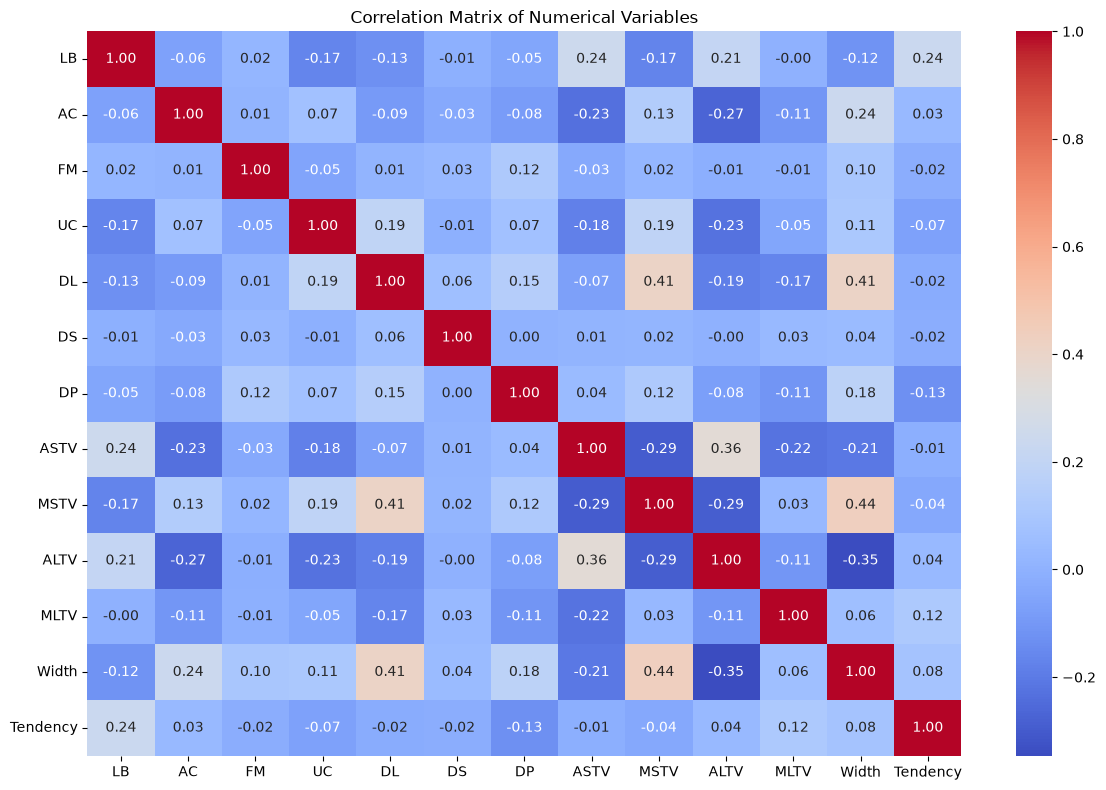

In [91]:
# Correlation matrix of numerical variables

plt.figure(figsize=(12, 8))

correlation_matrix = df[numeric_columns].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

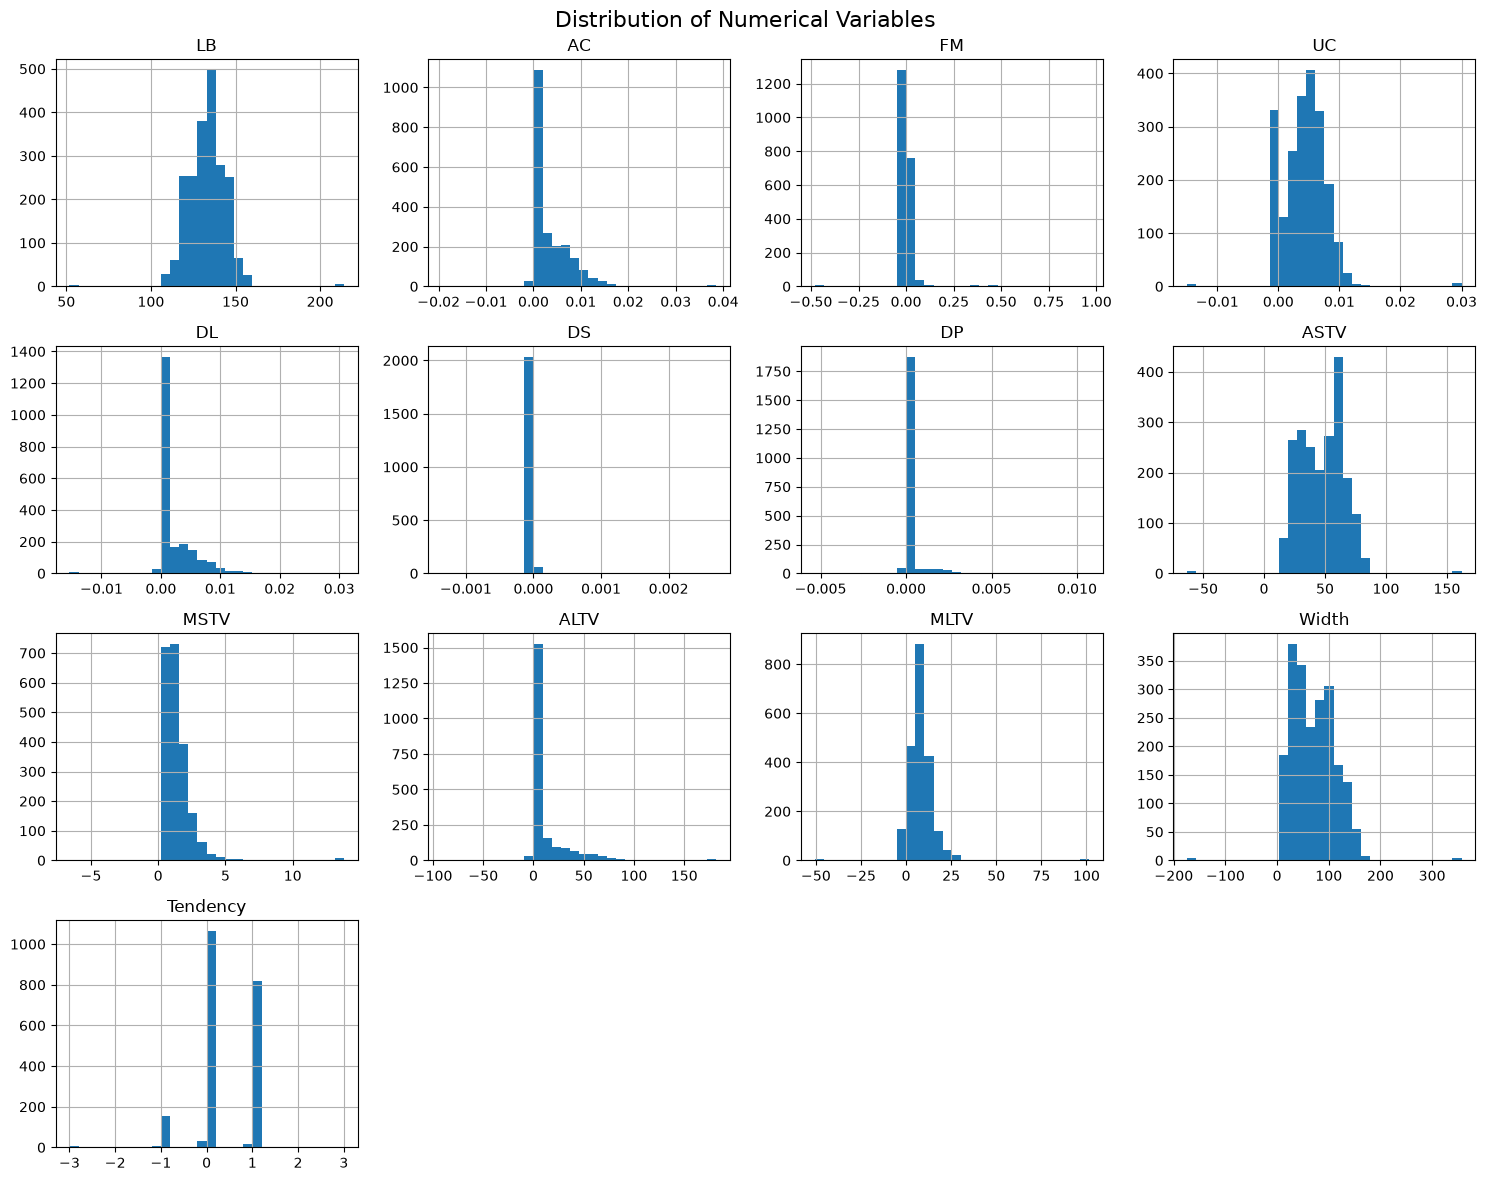

In [92]:
# Distribution of numerical variables

df[numeric_columns].hist(
    figsize=(15, 12),
    bins=30
)

plt.suptitle("Distribution of Numerical Variables", fontsize=16)
plt.tight_layout()
plt.show()

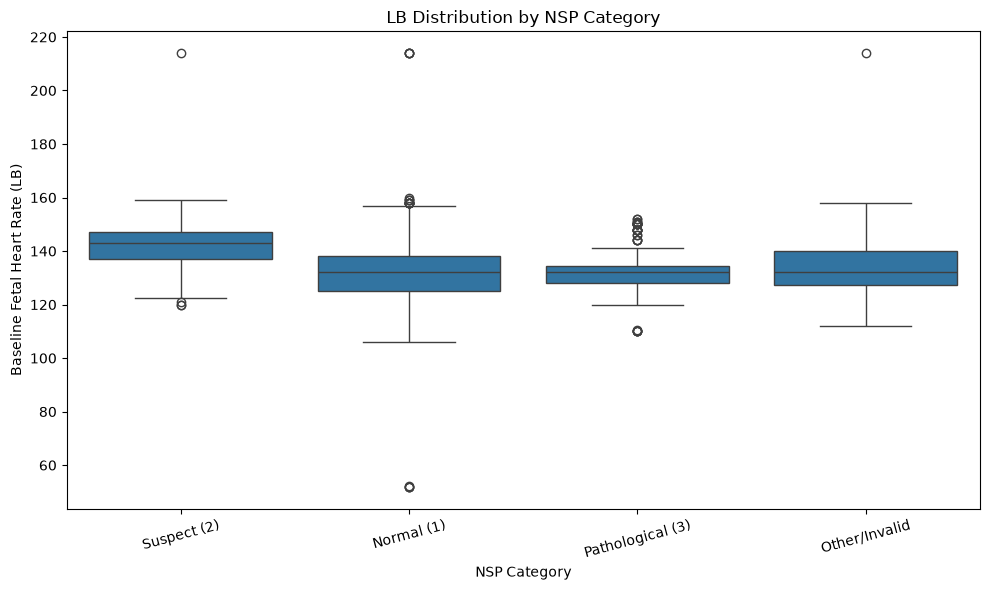

In [93]:
# Convert NSP values into meaningful categories

def categorize_nsp(value):
    if value == 1:
        return "Normal (1)"
    elif value == 2:
        return "Suspect (2)"
    elif value == 3:
        return "Pathological (3)"
    else:
        return "Other/Invalid"

df["NSP_Category"] = df["NSP"].apply(categorize_nsp)

# Boxplot of LB by NSP category

plt.figure(figsize=(10, 6))

sns.boxplot(
    x="NSP_Category",
    y="LB",
    data=df
)

plt.title("LB Distribution by NSP Category")
plt.xlabel("NSP Category")
plt.ylabel("Baseline Fetal Heart Rate (LB)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

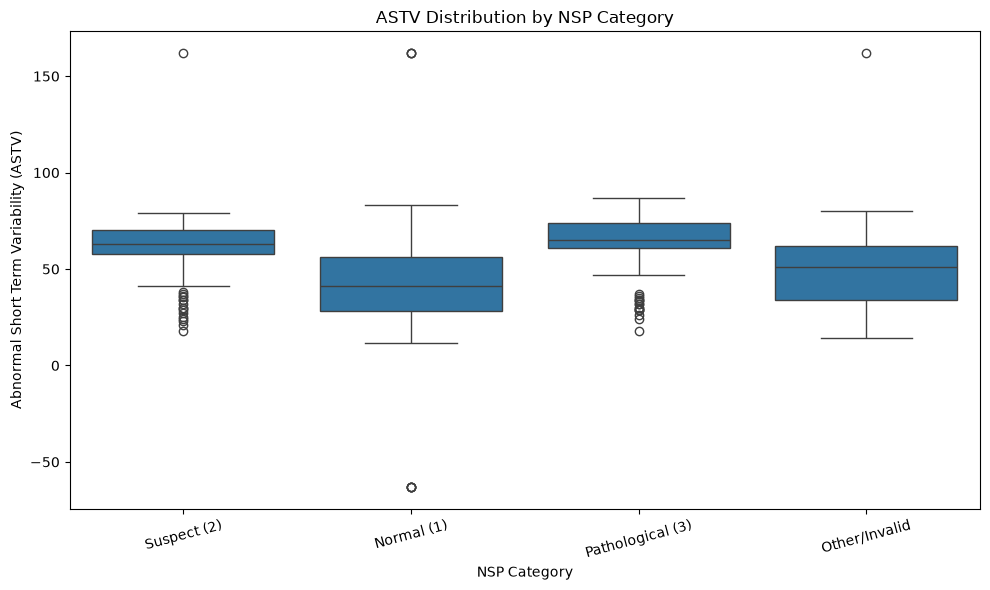

In [94]:
# ASTV distribution by NSP category

plt.figure(figsize=(10, 6))

sns.boxplot(
    x="NSP_Category",
    y="ASTV",
    data=df
)

plt.title("ASTV Distribution by NSP Category")
plt.xlabel("NSP Category")
plt.ylabel("Abnormal Short Term Variability (ASTV)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

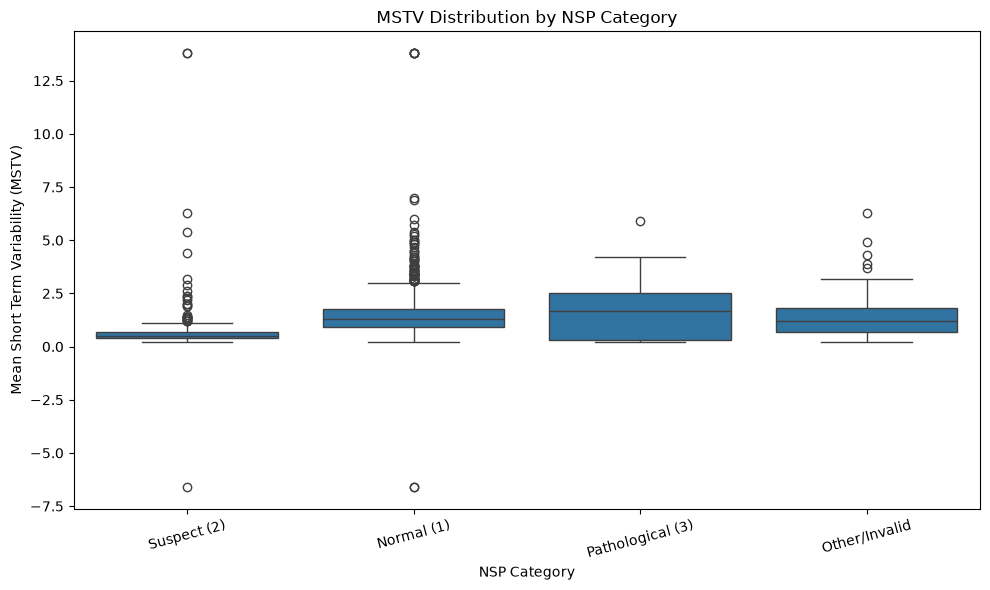

In [95]:
# MSTV distribution by NSP category

plt.figure(figsize=(10, 6))

sns.boxplot(
    x="NSP_Category",
    y="MSTV",
    data=df
)

plt.title("MSTV Distribution by NSP Category")
plt.xlabel("NSP Category")
plt.ylabel("Mean Short Term Variability (MSTV)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

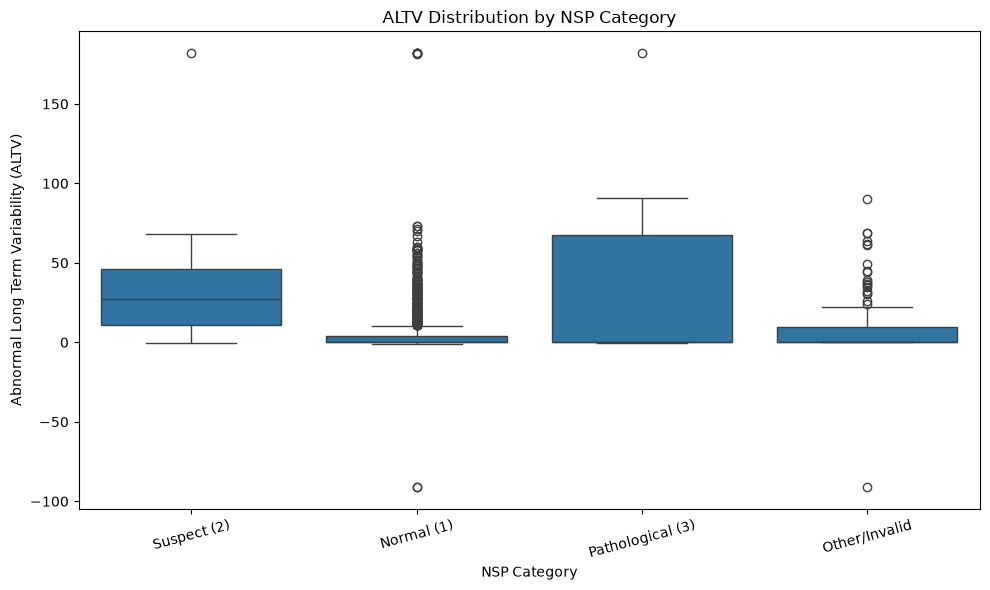

In [96]:
# ALTV distribution by NSP category

plt.figure(figsize=(10, 6))

sns.boxplot(
    x="NSP_Category",
    y="ALTV",
    data=df
)

plt.title("ALTV Distribution by NSP Category")
plt.xlabel("NSP Category")
plt.ylabel("Abnormal Long Term Variability (ALTV)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

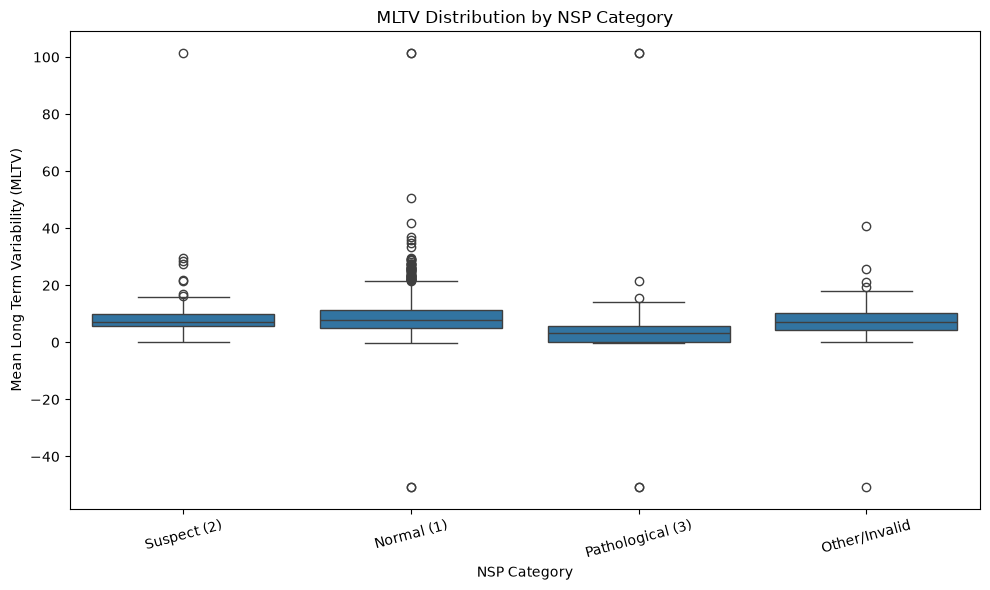

In [97]:
# MLTV distribution by NSP category

plt.figure(figsize=(10, 6))

sns.boxplot(
    x="NSP_Category",
    y="MLTV",
    data=df
)

plt.title("MLTV Distribution by NSP Category")
plt.xlabel("NSP Category")
plt.ylabel("Mean Long Term Variability (MLTV)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

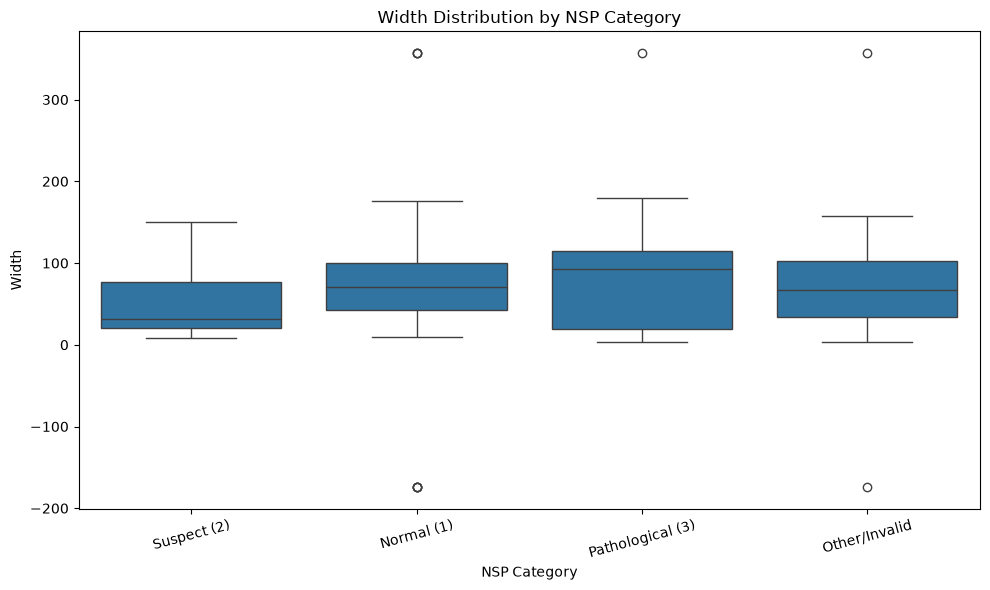

In [98]:
# Width distribution by NSP category

plt.figure(figsize=(10, 6))

sns.boxplot(
    x="NSP_Category",
    y="Width",
    data=df
)

plt.title("Width Distribution by NSP Category")
plt.xlabel("NSP Category")
plt.ylabel("Width")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

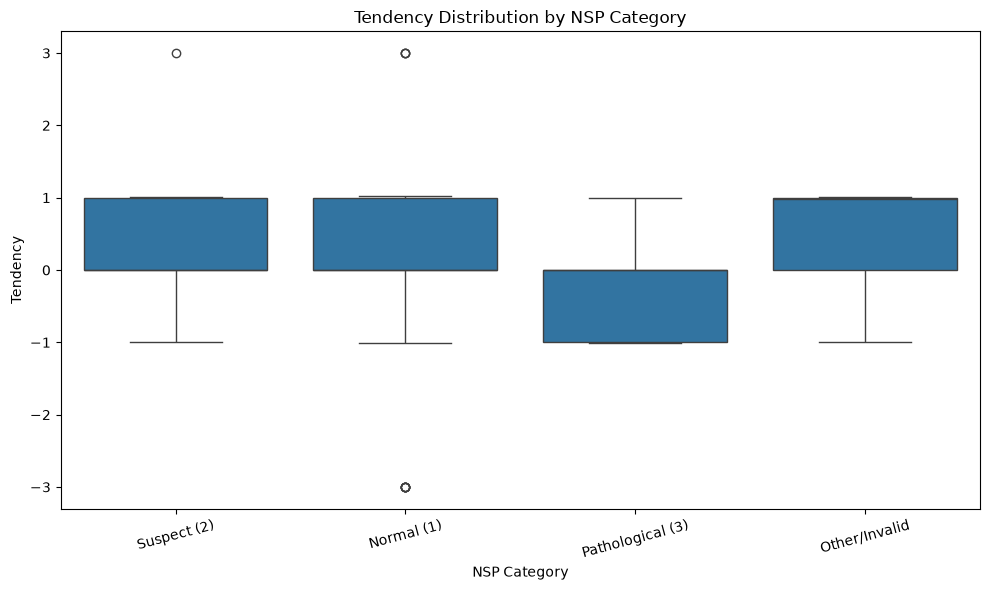

In [99]:
# Tendency distribution by NSP category

plt.figure(figsize=(10, 6))

sns.boxplot(
    x="NSP_Category",
    y="Tendency",
    data=df
)

plt.title("Tendency Distribution by NSP Category")
plt.xlabel("NSP Category")
plt.ylabel("Tendency")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [100]:
# Tuple Operations

numbers = (10, 20, 30, 40, 50)

print("Tuple:", numbers)
print("First element:", numbers[0])
print("Last element:", numbers[-1])
print("Length:", len(numbers))
print("Count of 20:", numbers.count(20))
print("Index of 30:", numbers.index(30))

Tuple: (10, 20, 30, 40, 50)
First element: 10
Last element: 50
Length: 5
Count of 20: 1
Index of 30: 2


In [101]:
# Tuple Immutability Example

colors = ("Red", "Green", "Blue")

print(colors)

# colors[0] = "Yellow"
# This gives an error because tuples are immutable.

('Red', 'Green', 'Blue')


In [102]:
# Remove duplicates using Set

values = [1, 2, 2, 3, 4, 4, 5]

unique_values = set(values)

print("Original List:", values)
print("After Removing Duplicates:", unique_values)

Original List: [1, 2, 2, 3, 4, 4, 5]
After Removing Duplicates: {1, 2, 3, 4, 5}


In [103]:
# Dictionary Update

student = {
    "Name": "John",
    "Age": 20,
    "Course": "Python"
}

print("Original Dictionary:", student)

student["Age"] = 21
student["City"] = "Delhi"

print("Updated Dictionary:", student)

Original Dictionary: {'Name': 'John', 'Age': 20, 'Course': 'Python'}
Updated Dictionary: {'Name': 'John', 'Age': 21, 'Course': 'Python', 'City': 'Delhi'}


In [104]:
age = 19

if age >= 18:
    print("Eligible for Voting")
else:
    print("Not Eligible for Voting")

Eligible for Voting


In [105]:
marks = 82

if marks >= 90:
    print("Grade A")
elif marks >= 75:
    print("Grade B")
elif marks >= 50:
    print("Grade C")
else:
    print("Fail")

Grade B


In [106]:
num = 8

if num > 0:
    print("Positive Number")
elif num < 0:
    print("Negative Number")
else:
    print("Zero")

if num % 2 == 0:
    print("Even Number")
else:
    print("Odd Number")

Positive Number
Even Number


In [107]:
import numpy as np
import pandas as pd

In [108]:
arr = np.array([10, 20, 30, 40])

print("Original Array:", arr)
print("Add 5:", arr + 5)
print("Subtract 5:", arr - 5)
print("Multiply by 2:", arr * 2)
print("Divide by 2:", arr / 2)

Original Array: [10 20 30 40]
Add 5: [15 25 35 45]
Subtract 5: [ 5 15 25 35]
Multiply by 2: [20 40 60 80]
Divide by 2: [ 5. 10. 15. 20.]


In [109]:
array_1d = np.array([1, 2, 3, 4, 5])

print(array_1d)

[1 2 3 4 5]


In [110]:
array_2d = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

print(array_2d)

[[1 2 3]
 [4 5 6]
 [7 8 9]]


In [111]:
random_array = np.random.rand(4, 4)

print(random_array)

[[0.39799713 0.80205185 0.09109802 0.53765826]
 [0.47457735 0.08122097 0.22327954 0.108789  ]
 [0.30451338 0.54166927 0.94168998 0.48277422]
 [0.98401571 0.10044284 0.15627354 0.88446347]]


In [112]:
df_array = pd.DataFrame(
    random_array,
    columns=["A", "B", "C", "D"]
)

print(df_array)

          A         B         C         D
0  0.397997  0.802052  0.091098  0.537658
1  0.474577  0.081221  0.223280  0.108789
2  0.304513  0.541669  0.941690  0.482774
3  0.984016  0.100443  0.156274  0.884463


In [113]:
data = {
    "Name": ["Alice", "Bob", "Charlie", "David", "Bob"],
    "Age": [25, 30, 35, 28, 30],
    "Salary": [50000, np.nan, 70000, 60000, np.nan],
    "Department": ["HR", "IT", "Finance", "IT", "IT"]
}

df = pd.DataFrame(data)

print(df)

      Name  Age   Salary Department
0    Alice   25  50000.0         HR
1      Bob   30      NaN         IT
2  Charlie   35  70000.0    Finance
3    David   28  60000.0         IT
4      Bob   30      NaN         IT


In [114]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        5 non-null      str    
 1   Age         5 non-null      int64  
 2   Salary      3 non-null      float64
 3   Department  5 non-null      str    
dtypes: float64(1), int64(1), str(2)
memory usage: 292.0 bytes


In [115]:
print(df.describe())

             Age   Salary
count   5.000000      3.0
mean   29.600000  60000.0
std     3.646917  10000.0
min    25.000000  50000.0
25%    28.000000  55000.0
50%    30.000000  60000.0
75%    30.000000  65000.0
max    35.000000  70000.0


In [116]:
# Select one column
print(df["Name"])

# Select multiple columns
print(df[["Name", "Salary"]])

# Add a new column
df["Bonus"] = df["Salary"] * 0.10

print(df)

0      Alice
1        Bob
2    Charlie
3      David
4        Bob
Name: Name, dtype: str
      Name   Salary
0    Alice  50000.0
1      Bob      NaN
2  Charlie  70000.0
3    David  60000.0
4      Bob      NaN
      Name  Age   Salary Department   Bonus
0    Alice   25  50000.0         HR  5000.0
1      Bob   30      NaN         IT     NaN
2  Charlie   35  70000.0    Finance  7000.0
3    David   28  60000.0         IT  6000.0
4      Bob   30      NaN         IT     NaN


In [117]:
mean_salary = df["Salary"].mean()

df["Salary"] = df["Salary"].fillna(mean_salary)

print(df)

      Name  Age   Salary Department   Bonus
0    Alice   25  50000.0         HR  5000.0
1      Bob   30  60000.0         IT     NaN
2  Charlie   35  70000.0    Finance  7000.0
3    David   28  60000.0         IT  6000.0
4      Bob   30  60000.0         IT     NaN


In [118]:
print("Before removing duplicates:")
print(df)

df = df.drop_duplicates()

print("\nAfter removing duplicates:")
print(df)

Before removing duplicates:
      Name  Age   Salary Department   Bonus
0    Alice   25  50000.0         HR  5000.0
1      Bob   30  60000.0         IT     NaN
2  Charlie   35  70000.0    Finance  7000.0
3    David   28  60000.0         IT  6000.0
4      Bob   30  60000.0         IT     NaN

After removing duplicates:
      Name  Age   Salary Department   Bonus
0    Alice   25  50000.0         HR  5000.0
1      Bob   30  60000.0         IT     NaN
2  Charlie   35  70000.0    Finance  7000.0
3    David   28  60000.0         IT  6000.0
